IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

IMPORT DATASET

In [2]:
annonimized = pd.read_csv("annonimized.csv")
diemQT = pd.read_csv("qt-public.csv")

print(annonimized.shape)
print(diemQT.shape) 


(295198, 11)
(761, 2)


DATASET OVERVIEW

In [3]:
# Explore annonimized dataset structure
print("=== Annonimized Dataset Analysis ===")
print(f"Columns: {annonimized.columns.tolist()}")

# Check unique values for key columns
print(f"\nNumber of unique students: {annonimized['concat(\'it001\', username)'].nunique()}")
print(f"Number of unique assignments: {annonimized['concat(\'it001\',`assignment_id`)'].nunique()}")
print(f"Number of unique problems: {annonimized['concat(\'it001\',`problem_id`)'].nunique()}")

=== Annonimized Dataset Analysis ===
Columns: ["concat('it001',`assignment_id`)", "concat('it001',`problem_id`)", "concat('it001', username)", 'is_final', 'status', 'pre_score', 'coefficient', "concat('it001',`language_id`)", 'created_at', 'updated_at', 'judgement']

Number of unique students: 1489
Number of unique assignments: 203
Number of unique problems: 469


DATASET PREPROCESSING

In [4]:
import json

# Trích xuất thông tin cần thiết từ annonimized
annonimized_extracted = annonimized[[
    "concat('it001',`assignment_id`)",
    "concat('it001',`problem_id`)",
    "concat('it001', username)",
    "is_final",
    "status",
    "coefficient",
    "pre_score",
    "created_at",
    "updated_at",
    "judgement"
]].copy()

# Đổi tên cột cho dễ hiểu
annonimized_extracted.columns = [
    "assignment_id",
    "problem_id",
    "student",
    "is_final",
    "status",
    "late_coef",
    "score_percent",
    "submit_time",
    "grade_time",
    "judgement"
]

#Chỉ giữa lại các cột cần thiết
annonimized_extracted = annonimized_extracted[[
    "assignment_id",
    "problem_id",
    "student",
    "is_final",
    "status",
    "late_coef",
    "score_percent",
]]

annonimized_extracted.head()

,assignment_id,problem_id,student,is_final,status,late_coef,score_percent
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,100,0
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,100,0
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,100,10000
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,100,10000
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,100,10000


In [5]:
# Tạo các features tổng hợp cho mỗi sinh viên
student_features = annonimized_extracted.groupby('student').agg(
    num_submissions=('student', 'count'),  # Tổng số lần nộp bài
    num_score_100=('score_percent', lambda x: (x == 10000).sum()),  # Số lần đạt 100% testcase
    num_unique_problems=('problem_id', 'nunique'),  # Số bài tập unique đã làm
    num_unique_assignments=('assignment_id', 'nunique'),  # Số assignment unique đã làm
    avg_score_percent=('score_percent', 'mean'),  # Điểm trung bình các lần nộp
    avg_late_coef=('late_coef', 'mean'),  # Hệ số trễ trung bình
    num_final_submissions=('is_final', lambda x: (x == 1).sum()),  # Số lần nộp tính điểm
    num_non_final_submissions=('is_final', lambda x: (x == 0).sum()), # Số lần nộp không tính điểm
    total_status_ok=('status', lambda x: (x == "SCORE").sum()),  # Số lần code chạy được
    total_status_error=('status', lambda x: (x == "Compilation Error").sum()),  # Số lần code bị lỗi
    num_late=('late_coef', lambda x: (x > 0).sum()),
    num_on_time=('late_coef', lambda x: (x == 0).sum()),
).reset_index()


student_features['ratio_score_100'] = student_features['num_score_100'] / student_features['num_submissions']
student_features['avg_score_percent'] = (student_features['avg_score_percent'] / 10000).round(2)  
student_features['avg_score_percent'] = student_features['avg_score_percent'].round(2)
student_features['avg_late_coef'] = student_features['avg_late_coef'].round(2)
student_features['ratio_score_100'] = student_features['ratio_score_100'].round(6)


student_features.head()

,student,num_submissions,num_score_100,num_unique_problems,num_unique_assignments,avg_score_percent,avg_late_coef,num_final_submissions,num_non_final_submissions,total_status_ok,total_status_error,num_late,num_on_time,ratio_score_100
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,147,54,46,7,0.55,100.0,46,101,119,28,147,0,0.367347
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,259,85,78,9,0.55,100.0,78,181,209,50,259,0,0.328185
2,01122b3ef7e59b84189e65985305f575d6bdf83c,195,59,66,7,0.60,100.0,67,128,175,20,195,0,0.302564
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,100,52,47,4,0.60,100.0,47,53,76,24,100,0,0.520000
4,013de369c439ab0ead8aa7da64423aa395a8be39,107,59,52,8,0.65,97.2,66,41,94,13,104,3,0.551402


In [6]:
diemQT['diemqt'] = pd.to_numeric(diemQT['diemqt'], errors='coerce')

In [7]:
# Merge student_features với diemQT dựa trên student ID
student_merged_data = student_features.merge(diemQT[['hash', 'diemqt']], 
                                    how='left', 
                                    left_on='student', 
                                    right_on='hash')

# Xóa cột hash không cần thiết
merged_data = student_merged_data.drop(columns=['hash'])
merged_data.head()

,student,num_submissions,num_score_100,num_unique_problems,num_unique_assignments,avg_score_percent,avg_late_coef,num_final_submissions,num_non_final_submissions,total_status_ok,total_status_error,num_late,num_on_time,ratio_score_100,diemqt
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,147,54,46,7,0.55,100.0,46,101,119,28,147,0,0.367347,7.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,259,85,78,9,0.55,100.0,78,181,209,50,259,0,0.328185,7.0
2,01122b3ef7e59b84189e65985305f575d6bdf83c,195,59,66,7,0.60,100.0,67,128,175,20,195,0,0.302564,9.0
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,100,52,47,4,0.60,100.0,47,53,76,24,100,0,0.520000,NaN
4,013de369c439ab0ead8aa7da64423aa395a8be39,107,59,52,8,0.65,97.2,66,41,94,13,104,3,0.551402,10.0


In [8]:
graded = merged_data[merged_data['diemqt'].notnull()].copy()
ungraded = merged_data[merged_data['diemqt'].isnull()].copy()

In [9]:
graded

,student,num_submissions,num_score_100,num_unique_problems,num_unique_assignments,avg_score_percent,avg_late_coef,num_final_submissions,num_non_final_submissions,total_status_ok,total_status_error,num_late,num_on_time,ratio_score_100,diemqt
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,147,54,46,7,0.55,100.0,46,101,119,28,147,0,0.367347,7.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,259,85,78,9,0.55,100.0,78,181,209,50,259,0,0.328185,7.0
2,01122b3ef7e59b84189e65985305f575d6bdf83c,195,59,66,7,0.60,100.0,67,128,175,20,195,0,0.302564,9.0
4,013de369c439ab0ead8aa7da64423aa395a8be39,107,59,52,8,0.65,97.2,66,41,94,13,104,3,0.551402,10.0
5,014c59c6433fd764a0b08de6ffeb757eaf60aa73,199,79,90,9,0.52,100.0,90,109,154,45,199,0,0.396985,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,840d07858c03f80f4695056e2cc7d0c474b83a25,111,41,43,6,0.52,100.0,44,67,81,30,111,0,0.369369,9.0
797,844f5db2e7e31ae51eba025480679ed7e4708ac6,357,108,104,17,0.48,100.0,104,253,254,103,357,0,0.302521,8.0
798,845acd04a77b3d1b623f255d9f9f8eae90892dab,155,47,52,8,0.42,100.0,53,102,117,38,155,0,0.303226,6.5
799,8460eaaf887a6289fb156f7562fb739ba8e9629e,557,113,114,12,0.43,100.0,115,442,416,141,557,0,0.202873,10.0


In [10]:
ungraded

,student,num_submissions,num_score_100,num_unique_problems,num_unique_assignments,avg_score_percent,avg_late_coef,num_final_submissions,num_non_final_submissions,total_status_ok,total_status_error,num_late,num_on_time,ratio_score_100,diemqt
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,100,52,47,4,0.60,100.0,47,53,76,24,100,0,0.520000,NaN
20,035f97702f2c01d26ab1fae8f39ea2f98a0caa3c,144,52,50,4,0.50,100.0,50,94,103,41,144,0,0.361111,NaN
40,06024da8147b5cf6105beb4c403f67cf1ff0aea1,8,5,5,1,0.68,100.0,5,3,8,0,8,0,0.625000,NaN
68,0aaebc88f6106684d6993c156104c1ef36cf94e0,192,53,50,4,0.41,100.0,50,142,149,43,192,0,0.276042,NaN
80,0bf111a9caedf02804f6991792490e63bc21058a,199,79,65,6,0.64,100.0,82,117,176,23,199,0,0.396985,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,feb8a2859a011c59efd22ed419cb69288fe03627,74,40,34,9,0.56,100.0,34,40,71,3,74,0,0.540541,NaN
1485,fef4a3263ed9a8ab14d457694bb8fd86ccd98312,260,80,77,6,0.62,100.0,78,182,216,44,260,0,0.307692,NaN
1486,ff12d6e2ab80696ed8e22fbe5497e96c68d29076,437,105,100,6,0.50,100.0,103,334,360,77,437,0,0.240275,NaN
1487,ff3fa2ec64294f37ae968159f810ebeda7966c51,94,30,34,7,0.43,100.0,34,60,74,20,94,0,0.319149,NaN


In [11]:
scaler = StandardScaler()

TRAIN MODEL


Model score (R^2): -0.0074786182942987445


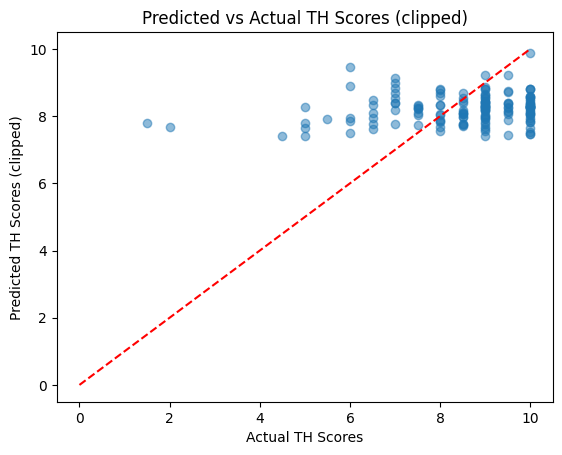

In [12]:

# Clean and prepare features and target for training
X = graded.drop(columns=['student', 'diemqt']) 
y = graded['diemqt'].astype(float)  

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train linear regression model
lr = LinearRegression()
# Dự đoán điểm
lr.fit(X_train, y_train)

# Dự đoán trên tập test
print("Model score (R^2):", lr.score(X_test, y_test))

# Vẽ biểu đồ so sánh
plt.scatter(y_test, lr.predict(X_test), alpha=0.5)
plt.xlabel('Actual TH Scores')
plt.ylabel('Predicted TH Scores (clipped)')
plt.title('Predicted vs Actual TH Scores (clipped)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') 
plt.show()

EXPORT DATA


In [13]:
# Chuẩn bị dữ liệu dự đoán cho tất cả sinh viên
all_students = merged_data.copy()

# Nếu có sinh viên chưa có điểm TH, vẫn phải dự đoán cho họ
X_all = all_students.drop(columns=["student", "diemqt"])  # Bỏ cột student và diemqt
X_all_scaled = scaler.transform(X_all)

# Dự đoán điểm
all_students["predicted_QT"] = lr.predict(X_all_scaled)

# Xuất file kết quả: chỉ cần 2 cột student và predicted_TH
all_students[["student", "predicted_QT"]].to_csv("predicted_QT.csv", index=False)
